# Classifying movie reviews. A binary classification

This notebook contains code from the book Deep Learning with Python by Francois Chollet
Chapter 3.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Set style for visualizations
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")

In this example, we will learn to classify movie reviews into "positive" reviews and "negative" reviews, just based on the text content of the reviews.

Test set has already been preprocessed: the reviews (sequences of words) have been turned into sequences of integers, where each integer stands for a specific word in a dictionary.

In [4]:
from tensorflow.keras.datasets import imdb

# Load IMDB movie reviews (num_words=10000 keeps top 10k most frequent words)
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



The argument `num_words=10000` means that we will only keep the top 10,000 most frequently occurring words in the training data. Rare words
will be discarded. This allows us to work with vector data of manageable size.

The variables `train_data` and `test_data` are lists of reviews, each review being a list of word indices (encoding a sequence of words).
`train_labels` and `test_labels` are lists of 0s and 1s, where 0 stands for "negative" and 1 stands for "positive":

In [5]:
print("train_data:", type(train_data), train_data.shape)
print("train_labels:", type(train_labels), train_labels.shape)
print("test_data:", type(test_data), test_data.shape)
print("test_labels:", type(test_labels), test_labels.shape)

train_data: <class 'numpy.ndarray'> (25000,)
train_labels: <class 'numpy.ndarray'> (25000,)
test_data: <class 'numpy.ndarray'> (25000,)
test_labels: <class 'numpy.ndarray'> (25000,)


In [6]:
print(type(train_data[1]), len(train_data[1]))
print(type(train_data[2]), len(train_data[2]))
print(type(train_data[3]), len(train_data[3]))
print(type(train_data[24001]), len(train_data[24001]))

<class 'list'> 189
<class 'list'> 141
<class 'list'> 550
<class 'list'> 158


In [7]:
print(type(train_data))
print(type(train_data[6]))

<class 'numpy.ndarray'>
<class 'list'>


In [8]:
train_data[6]

[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

/tmp/ipykernel_2753/2812069290.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Train', 'Test'])


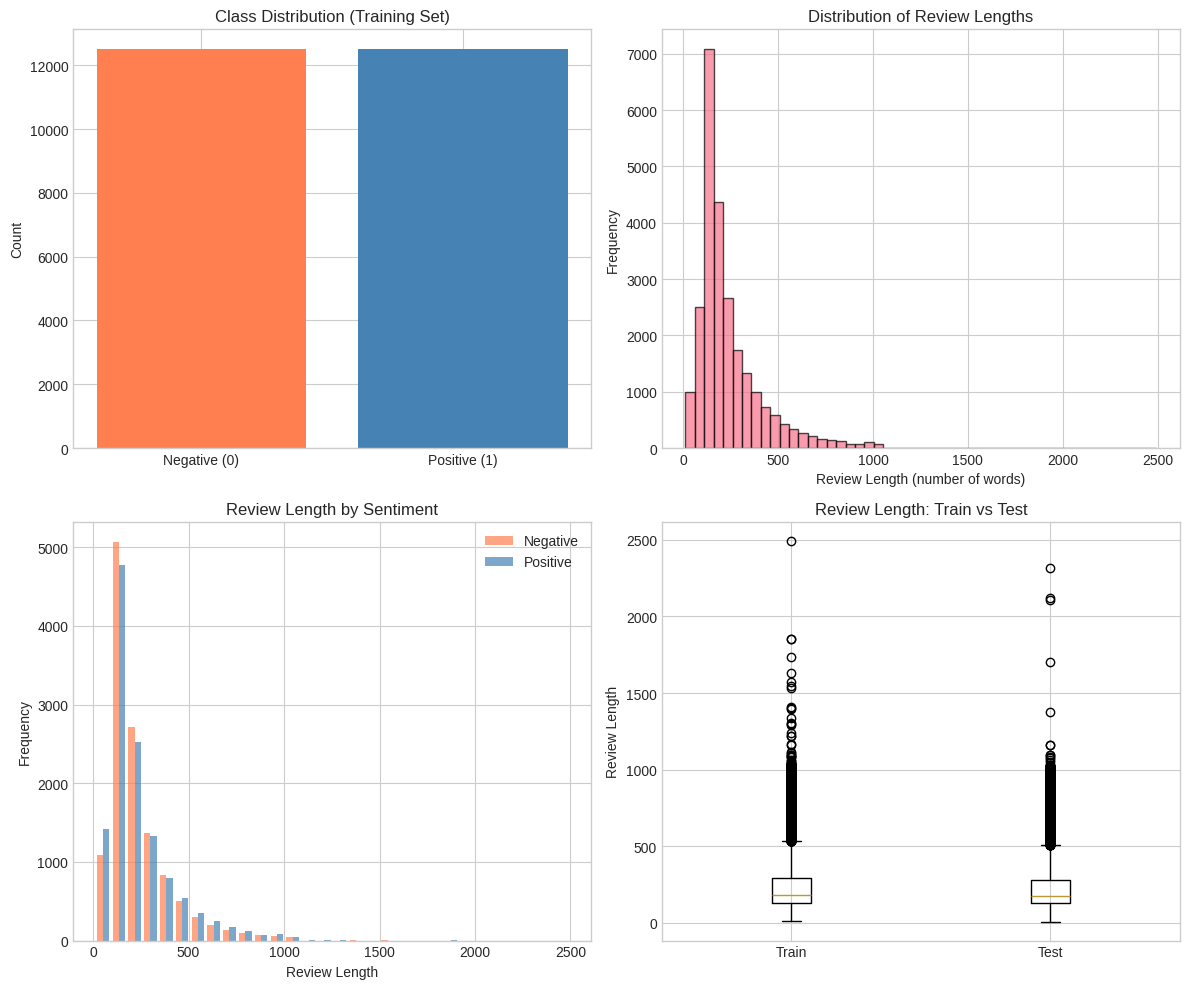

In [9]:
# Data exploration visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Class distribution (positive vs negative)
class_counts = pd.Series(train_labels).value_counts().sort_index()
axes[0, 0].bar(['Negative (0)', 'Positive (1)'], class_counts.values, color=['coral', 'steelblue'])
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Class Distribution (Training Set)')

# 2. Review length distribution
review_lengths = [len(seq) for seq in train_data]
axes[0, 1].hist(review_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Review Length (number of words)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Review Lengths')

# 3. Review length by class
neg_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 0]
pos_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 1]
axes[1, 0].hist([neg_lengths, pos_lengths], bins=30, label=['Negative', 'Positive'], alpha=0.7, color=['coral', 'steelblue'])
axes[1, 0].set_xlabel('Review Length')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Review Length by Sentiment')
axes[1, 0].legend()

# 4. Training vs Test - review length comparison
test_lengths = [len(seq) for seq in test_data]
axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Train', 'Test'])
axes[1, 1].set_ylabel('Review Length')
axes[1, 1].set_title('Review Length: Train vs Test')

plt.tight_layout()
plt.show()

We will refer to every small text representing a movie review as a sequnce. Sequences are made of numbers representing different words. Since we restricted ourselves to the top 10,000 most frequent words, no word index will exceed 10,000:

In [10]:
max([max(sequence) for sequence in train_data])

9999

You can quickly decode one of these reviews back to English words:

In [11]:
# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()
print(type(word_index), len(word_index))
# print(word_index.keys())
i = 0
for item in word_index.items():
    print(item)
    i = i + 1
    if(i > 4):
        break


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<class 'dict'> 88584
('fawn', 34701)
('tsukino', 52006)
('nunnery', 52007)
('sonja', 16816)
('vani', 63951)


In [12]:
# We reverse word_index, mapping integer indices to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
i = 0
for item in reverse_word_index.items():
    print(i,":",item)
    i = i + 1
    if(i > 4):
        break

0 : (34701, 'fawn')
1 : (52006, 'tsukino')
2 : (52007, 'nunnery')
3 : (16816, 'sonja')
4 : (63951, 'vani')


In [13]:
train_data[6]

[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

In [14]:
# We decode the reviews
# Please note when word_index was crated the indices were offset by 3
# because indeces: 0, 1 and 2 were reserved indices for "padding", "start of sequence", and "unknown".
# The third review, index 2, now reads in Eglish
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[6]])

In [15]:
decoded_review

"? lavish production values and solid performances in this straightforward adaption of jane ? satirical classic about the marriage game within and between the classes in ? 18th century england northam and paltrow are a ? mixture as friends who must pass through ? and lies to discover that they love each other good humor is a ? virtue which goes a long way towards explaining the ? of the aged source material which has been toned down a bit in its harsh ? i liked the look of the film and how shots were set up and i thought it didn't rely too much on ? of head shots like most other films of the 80s and 90s do very good results"

In [16]:
# print(word_index['padding'], word_index['unknown'])
print(reverse_word_index.get(-2))
print(reverse_word_index.get(6737))
print(reverse_word_index.get(362))

None
lavish
production


In [17]:
# If you doubt the advice about shifting keys by 3, try without the shift:
decoded_review = ' '.join([reverse_word_index.get(i, '?') for i in train_data[6]])

In [18]:
decoded_review

"the boiled full involving to impressive boring this as murdering naschy br villain and suggestion need has of costumes b message to may of props this and concentrates concept issue skeptical to god's he is and unfolds movie women like isn't surely i'm and to toward in here's for from did having because very quality it is and starship really book is both too worked carl of and br of reviewer closer figure really there will originals things is far this make mistakes and was couldn't of few br of you to don't female than place she to was between that nothing dose movies get are and br yes female just its because many br of overly to descent people time very bland"

## Preparing the data


We cannot feed `train_data` and `test_data`, which are the lists of integers, into a neural network.
We have to turn our lists into tensors.

- We could pad our lists so that they all have the same length, and turn them into an integer tensor of shape `(samples, word_indices)`.
- We could one-hot-encode our lists to turn them into vectors of 0s and 1s. Concretely, this would mean for instance turning the sequence
`[3, 5]` into a 10,000-dimensional vector that would be all-zeros except for indices 3 and 5, which would be ones. Then, as the
first layer in our network we could use a `Dense` layer, capable of handling floating point vector data.

Let's vectorize our data, preparing one-hot-encoded vectors.

In [23]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # e.g. we are placing label 1.0 in position 389,
        # if a word with has value 389 in word_index dictorionary.
        # this is a bag of words model. We will come back to this later in the course
        results[i, sequence] = 1.  # set specific indices of results[i] to 1s

    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
print("shape of x_train: ", x_train.shape)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
print("shape of x_test: ", x_test.shape)

shape of x_train:  (25000, 10000)
shape of x_test:  (25000, 10000)


Here's what our samples look like now:

In [24]:
x_train.shape

(25000, 10000)

In [25]:
print("len x[0]:", len(x_train[0]),"\n", x_train[0])
print("len x[10000]:", len(x_train[10000]),"\n", x_train[0])

len x[0]: 10000 
 [0. 1. 1. ... 0. 0. 0.]
len x[10000]: 10000 
 [0. 1. 1. ... 0. 0. 0.]


In [26]:
# The following illustrates how we assigned number 1 to every element
# of a row that corresponds to a word index in x_train.
illustration = np.zeros((3,5))
print(illustration)
sentences=[[0,4],[2,3],[4,3,4]]
for i in range(0,3):
    illustration[i,sentences[i]] = 1.0

print("\n",illustration)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 1.]
 [0. 0. 1. 1. 0.]
 [0. 0. 0. 1. 1.]]


We should also vectorize our labels, which is straightforward:

In [27]:
# Our vectorized labels
import numpy as np
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [28]:
print(y_train[0:8])

[1. 0. 0. 1. 0. 0. 1. 0.]


Now our data is ready to be fed into a neural network.

## Building our network


Our input data is simply vectors, and our labels are scalars (1s and 0s). A type of
network that performs well on such a problem would be a simple stack of fully-connected (`Dense`) layers with `relu` activations: `Dense(16,
activation='relu')`

Each such `Dense` layer with a `relu` activation implements
the following chain of tensor operations:

`output = relu(dot(W, input) + b)`

Having 16 hidden units means that the weight matrix `W` will have shape `(input_dimension, 16)`, i.e. the dot product with `W` will project the
input data onto a 16-dimensional representation space (and then we would add the bias vector `b` and apply the `relu` operation). In our case the `input` dimension is 10,000. There are 25,000 samples of dimension 10,000 each.

There are two key architecture decisions to make about such stack of dense layers:

* How many layers to use.
* How many "hidden units" to chose for each layer.


Sigmoid "squashes" arbitrary values into the `[0, 1]` interval, thus outputting something that can be interpreted as a probability.

### Keras implementation:

In [29]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We need to pick a loss function and an optimizer.
Since we are facing a binary classification problem and the output of our network is a probability (we end our network with a single-unit layer with a sigmoid activation), is it best to use the `binary_crossentropy` loss.
It isn't the only viable choice: you could use, for instance, `mean_squared_error`. But crossentropy is usually the best choice when you
are dealing with models that output probabilities.

Here's the step where we configure our model with the `rmsprop` optimizer and the `binary_crossentropy` loss function. Note that we will
also monitor accuracy during training.

In [30]:
model.compile(optimizer='rmsprop',   # 'adam' is a popular alternative
              loss='binary_crossentropy',
              metrics=['accuracy'])

We are passing our optimizer, loss function and metrics as strings, which is possible because `rmsprop`, `binary_crossentropy` and
`accuracy` are packaged as part of Keras. Sometimes you may want to configure the parameters of your optimizer, or pass a custom loss
function or metric function. This former can be done by passing an optimizer class instance as the `optimizer` argument:

In [31]:
from tensorflow.keras import optimizers

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

The latter can be done by passing function objects as the `loss` or `metrics` arguments:

In [32]:
from tensorflow.keras import losses
from tensorflow.keras import metrics

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

## Validating our approach

In order to verify the accuracy of the model on data that it has never seen before, we will create a "validation set" by
setting apart 10,000 samples from the original training data:

In [33]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

We will now train our model for 20 epochs (20 iterations over all samples in the `x_train` and `y_train` tensors), in mini-batches of 512
samples. At this same time we will monitor loss and accuracy on the 10,000 samples that we set apart. This is done by passing the
validation data as the `validation_data` argument:

In [34]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - binary_accuracy: 0.7901 - loss: 0.5083 - val_binary_accuracy: 0.8716 - val_loss: 0.3808
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - binary_accuracy: 0.8990 - loss: 0.3109 - val_binary_accuracy: 0.8869 - val_loss: 0.3062
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - binary_accuracy: 0.9235 - loss: 0.2331 - val_binary_accuracy: 0.8779 - val_loss: 0.2995
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - binary_accuracy: 0.9383 - loss: 0.1897 - val_binary_accuracy: 0.8878 - val_loss: 0.2771
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.9456 - loss: 0.1622 - val_binary_accuracy: 0.8878 - val_loss: 0.2766
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.9594 - loss: 0.1337 - val_binary_accuracy: 0.8876 - val_loss: 0.2846
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - binary_accuracy: 0.9639 - loss: 0.1156 - val_binary_accuracy: 0.8782 - val_loss: 0.3142
Epoch 8/20
30

On CPU, this will take less than two seconds per epoch -- training is over in 20 seconds. At the end of every epoch, there is a slight pause
as the model computes its loss and accuracy on the 10,000 samples of the validation data.

Note that the call to `model.fit()` returns a `History` object. This object has a member `history`, which is a dictionary containing data
about everything that happened during training. Let's take a look at it:

In [35]:
history_dict = history.history
history_dict.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

It contains 4 entries: one per metric that was being monitored, during training and during validation. Let's use Matplotlib to plot the
training and validation loss side by side, as well as the training and validation accuracy:

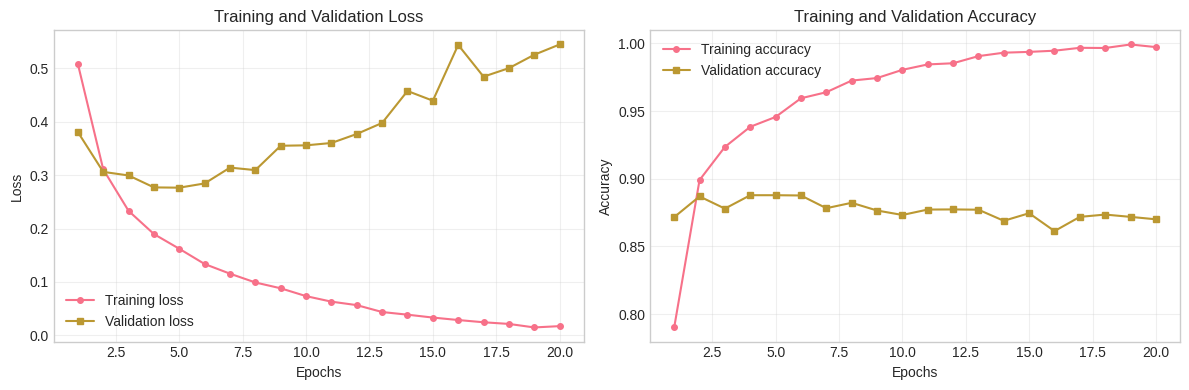

In [36]:
# Training history: Loss and Accuracy
history_dict = history.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, loss, 'o-', label='Training loss', markersize=4)
axes[0].plot(epochs, val_loss, 's-', label='Validation loss', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, acc, 'o-', label='Training accuracy', markersize=4)
axes[1].plot(epochs, val_acc, 's-', label='Validation accuracy', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Best epoch (lowest validation loss) - useful for early stopping
best_epoch = np.argmin(val_loss) + 1
print(f"Best epoch (lowest validation loss): {best_epoch}")

Best epoch (lowest validation loss): 5



The dots are the training loss and accuracy, while the solid lines are the validation loss and accuracy.

As you can see, the training loss decreases with every epoch and the training accuracy increases with every epoch. That's what you would
expect when running gradient descent optimization -- the quantity you are trying to minimize should get lower with every iteration. But that
isn't the case for the validation loss and accuracy: they seem to peak at the fourth epoch. This is an example of what we were warning
against earlier: a model that performs better on the training data isn't necessarily a model that will do better on data it has never seen
before. In precise terms, what you are seeing is "overfitting": after the second epoch, we are over-optimizing on the training data, and we
ended up learning representations that are specific to the training data and do not generalize to data outside of the training set.

In this case, to prevent overfitting, we could simply stop training after three epochs. In general, there is a range of techniques you can
leverage to mitigate overfitting, which we will cover in the next chapter.

Let's train a new network from scratch for four epochs, then evaluate it on our test data:

In [38]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8152 - loss: 0.4618
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9027 - loss: 0.2701
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9247 - loss: 0.2124
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9365 - loss: 0.1776
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8834 - loss: 0.2912


In [39]:
results

[0.2911933660507202, 0.8833600282669067]

Our fairly naive approach achieves an accuracy of 86%. With state-of-the-art approaches, one should be able to get close to 95%.

## Using a trained network to generate predictions on new data

After having trained a network, you will want to use it in a practical setting. You can generate the likelihood of reviews being positive
by using the `predict` method:

In [40]:
# Generate predictions (probabilities)
predictions = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


### Model evaluation visualizations

Below we visualize the model's predictions: confusion matrix, ROC curve, prediction distributions, and correct vs incorrect classifications.

As you can see, the network is very confident for some samples (0.99 or more, or 0.01 or less) but less confident for others (0.6, 0.4).


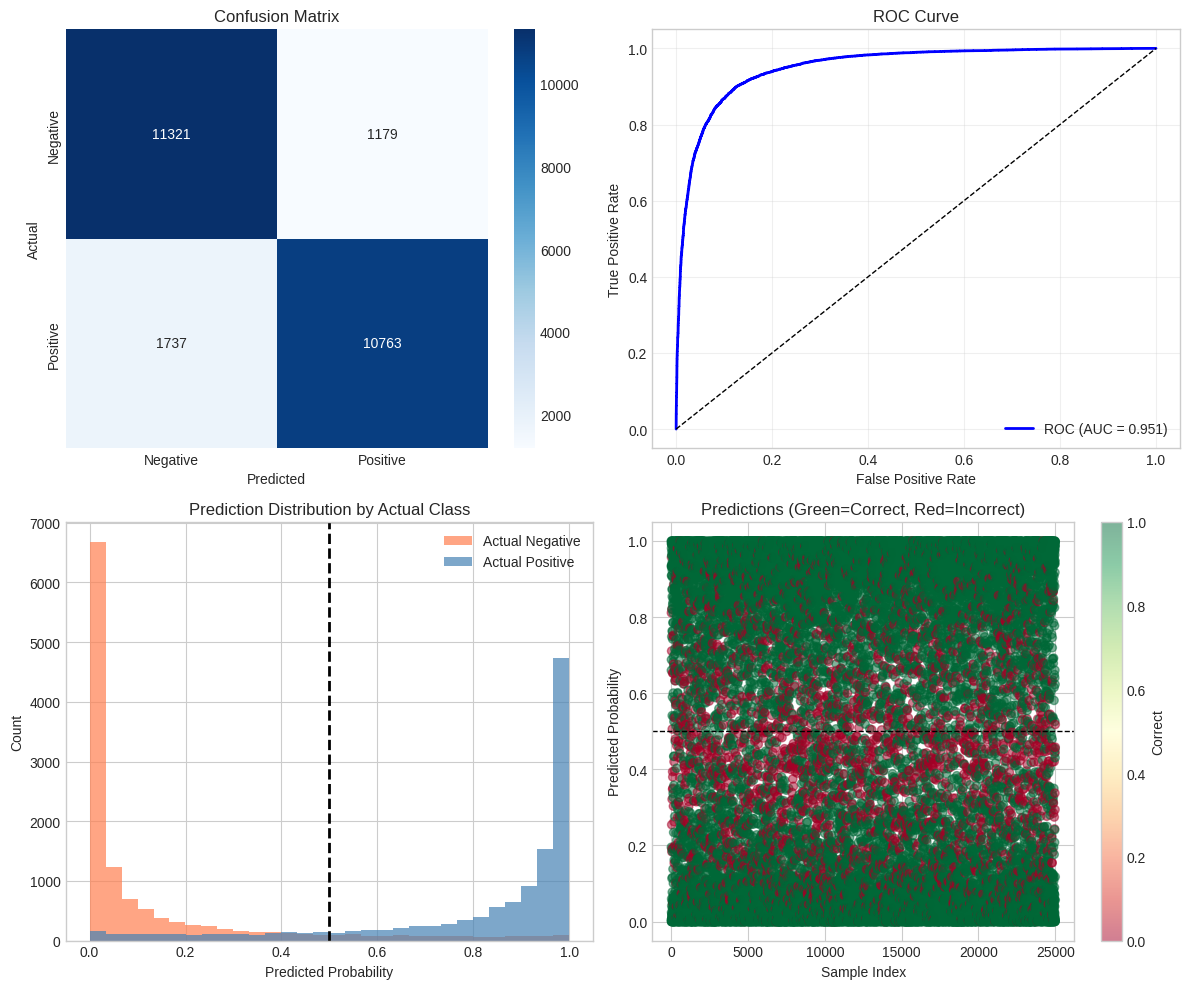

In [41]:
# Prediction visualizations
from sklearn.metrics import confusion_matrix, roc_curve, auc

pred_classes = (predictions.flatten() >= 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Confusion matrix
cm = confusion_matrix(y_test, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_title('Confusion Matrix')

# 2. ROC curve
fpr, tpr, _ = roc_curve(y_test, predictions.flatten())
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Prediction probability distribution by actual class
axes[1, 0].hist(predictions[y_test == 0].flatten(), bins=30, alpha=0.7, label='Actual Negative', color='coral')
axes[1, 0].hist(predictions[y_test == 1].flatten(), bins=30, alpha=0.7, label='Actual Positive', color='steelblue')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Probability')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Prediction Distribution by Actual Class')
axes[1, 0].legend()

# 4. Correct vs Incorrect predictions
correct = pred_classes == y_test
axes[1, 1].scatter(range(len(predictions)), predictions.flatten(), c=correct, cmap='RdYlGn', alpha=0.5)
axes[1, 1].axhline(y=0.5, color='black', linestyle='--', lw=1)
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Predicted Probability')
axes[1, 1].set_title('Predictions (Green=Correct, Red=Incorrect)')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Correct')

plt.tight_layout()
plt.show()

## Problema 3: Dropout

Probamos Dropout después de cada capa Dense(16) para combatir el overfitting.
10 pruebas en total: modelo base + 4 combinaciones de L1/L2, cada una con Dropout(0.25) y Dropout(0.10).

In [42]:
from tensorflow.keras import models, layers, regularizers, optimizers, losses, metrics
import matplotlib.pyplot as plt

# Función para graficar pérdida y precisión
def graficar(history, titulo):
    h = history.history
    loss = h['loss']
    val_loss = h['val_loss']
    acc = h['binary_accuracy']
    val_acc = h['val_binary_accuracy']
    epochs = range(1, len(loss) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')
    axes[0].plot(epochs, loss, 'o-', label='Training loss', markersize=4)
    axes[0].plot(epochs, val_loss, 's-', label='Validation loss', markersize=4)
    axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, acc, 'o-', label='Training accuracy', markersize=4)
    axes[1].plot(epochs, val_acc, 's-', label='Validation accuracy', markersize=4)
    axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# Función para construir modelo con Dropout y opcionalmente L1/L2
def construir_modelo(dropout_rate, l1=None, l2=None):
    reg = regularizers.l1_l2(l1=l1, l2=l2) if l1 is not None else None
    m = models.Sequential()
    m.add(layers.Dense(16, activation='relu', kernel_regularizer=reg, input_shape=(10000,)))
    m.add(layers.Dropout(dropout_rate))
    m.add(layers.Dense(16, activation='relu', kernel_regularizer=reg))
    m.add(layers.Dropout(dropout_rate))
    m.add(layers.Dense(1, activation='sigmoid'))
    m.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy, metrics=[metrics.binary_accuracy])
    return m

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - binary_accuracy: 0.7322 - loss: 0.5600 - val_binary_accuracy: 0.8666 - val_loss: 0.4122
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - binary_accuracy: 0.8515 - loss: 0.3916 - val_binary_accuracy: 0.8683 - val_loss: 0.3492
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - binary_accuracy: 0.8890 - loss: 0.3154 - val_binary_accuracy: 0.8886 - val_loss: 0.2931
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.9101 - loss: 0.2606 - val_binary_accuracy: 0.8865 - val_loss: 0.2832
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - binary_accuracy: 0.9288 - loss: 0.2150 - val_binary_accuracy: 0.8874 - val_loss: 0.2751
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - binary_accuracy: 0.9412 - loss: 0.1858 - val_binary_accuracy: 0.8896 - val_loss: 0.2739
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.9505 - loss: 0.1559 - val_binary_accuracy: 0.8852 - val_loss: 0.2889
Epoch 8/20
30

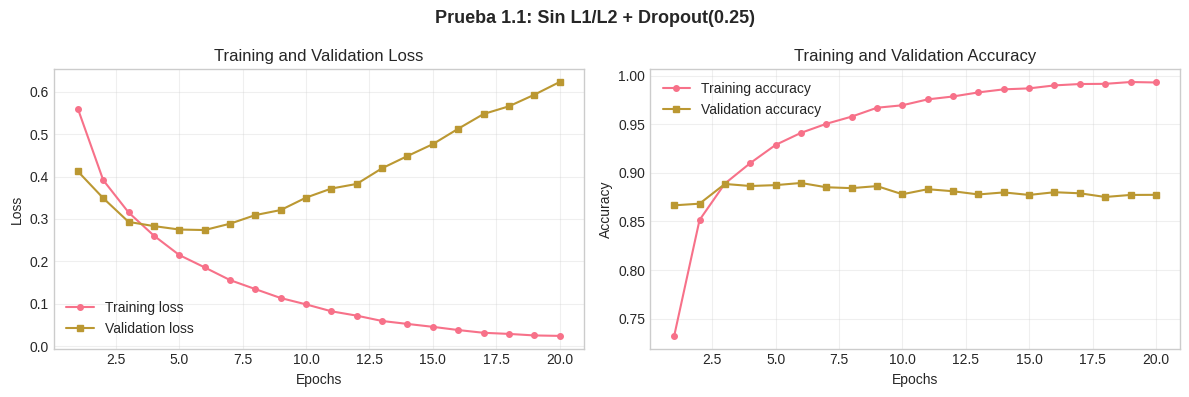

In [43]:
# PRUEBA 1.1: Sin L1/L2 + Dropout(0.25) - apaga 25% de neuronas
m = construir_modelo(dropout_rate=0.25)
h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
graficar(h, 'Prueba 1.1: Sin L1/L2 + Dropout(0.25)')

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - binary_accuracy: 0.7336 - loss: 0.5769 - val_binary_accuracy: 0.8639 - val_loss: 0.4285
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - binary_accuracy: 0.8665 - loss: 0.3793 - val_binary_accuracy: 0.8815 - val_loss: 0.3318
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.8952 - loss: 0.2925 - val_binary_accuracy: 0.8876 - val_loss: 0.2943
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - binary_accuracy: 0.9180 - loss: 0.2358 - val_binary_accuracy: 0.8707 - val_loss: 0.3127
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.9305 - loss: 0.2002 - val_binary_accuracy: 0.8882 - val_loss: 0.2774
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.9450 - loss: 0.1686 - val_binary_accuracy: 0.8845 - val_loss: 0.2852
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - binary_accuracy: 0.9562 - loss: 0.1410 - val_binary_accuracy: 0.8859 - val_loss: 0.2910
Epoch 8/20
30

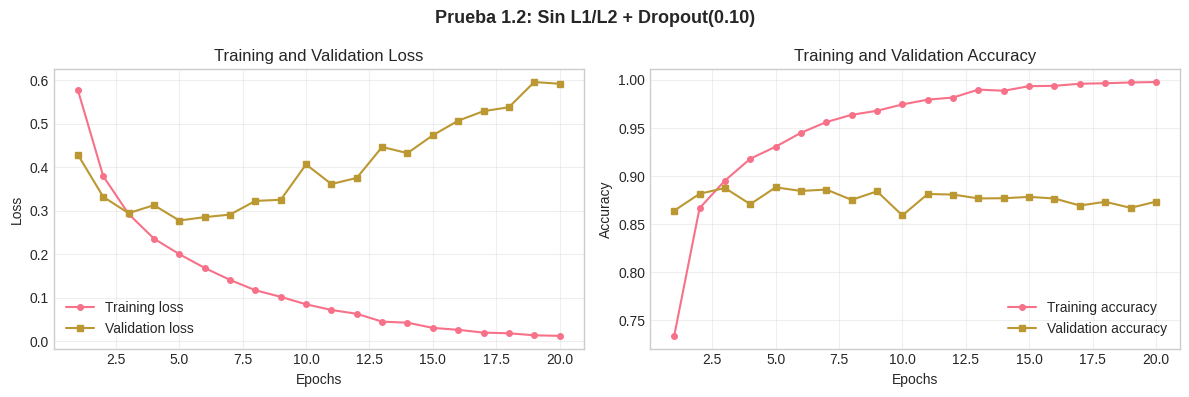

In [44]:
# PRUEBA 1.2: Sin L1/L2 + Dropout(0.10) - apaga 10% de neuronas
m = construir_modelo(dropout_rate=0.10)
h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
graficar(h, 'Prueba 1.2: Sin L1/L2 + Dropout(0.10)')

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - binary_accuracy: 0.5380 - loss: 5.0669 - val_binary_accuracy: 0.5499 - val_loss: 2.0447
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - binary_accuracy: 0.5738 - loss: 2.0046 - val_binary_accuracy: 0.4959 - val_loss: 1.9515
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.5967 - loss: 1.9148 - val_binary_accuracy: 0.7188 - val_loss: 1.8689
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - binary_accuracy: 0.6101 - loss: 1.8395 - val_binary_accuracy: 0.6566 - val_loss: 1.7989
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - binary_accuracy: 0.6226 - loss: 1.7724 - val_binary_accuracy: 0.6375 - val_loss: 1.7383
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - binary_accuracy: 0.6177 - loss: 1.7152 - val_binary_accuracy: 0.6426 - val_loss: 1.6849
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.6147 - loss: 1.6670 - val_binary_accuracy: 0.6724 - val_loss: 1.6416
Epoch 8/20
30

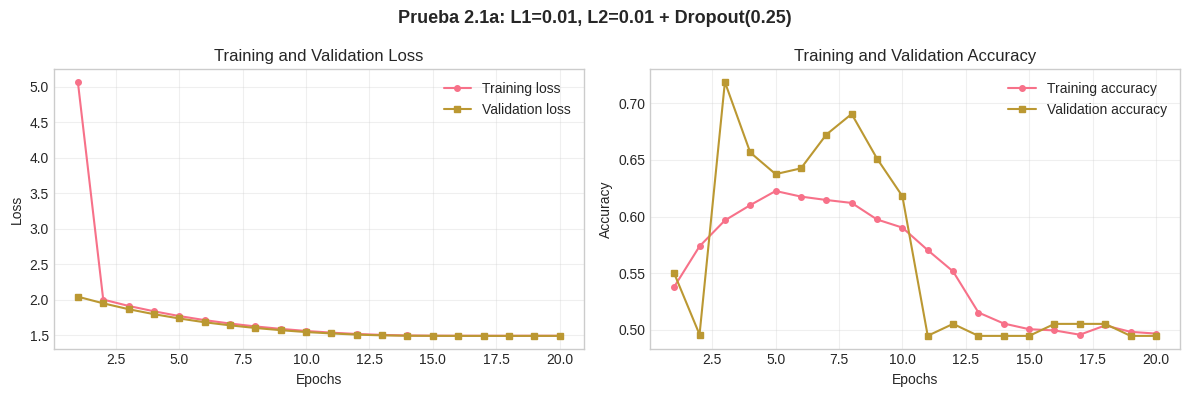

In [45]:
# PRUEBA 2.1a: L1=0.01, L2=0.01 + Dropout(0.25)
m = construir_modelo(dropout_rate=0.25, l1=0.01, l2=0.01)
h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
graficar(h, 'Prueba 2.1a: L1=0.01, L2=0.01 + Dropout(0.25)')

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - binary_accuracy: 0.5230 - loss: 5.1470 - val_binary_accuracy: 0.5736 - val_loss: 2.1193
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - binary_accuracy: 0.5483 - loss: 2.0784 - val_binary_accuracy: 0.6246 - val_loss: 2.0101
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - binary_accuracy: 0.5896 - loss: 1.9811 - val_binary_accuracy: 0.5631 - val_loss: 1.9232
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.6176 - loss: 1.8967 - val_binary_accuracy: 0.6988 - val_loss: 1.8448
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - binary_accuracy: 0.6332 - loss: 1.8207 - val_binary_accuracy: 0.5878 - val_loss: 1.7779
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.6286 - loss: 1.7561 - val_binary_accuracy: 0.6112 - val_loss: 1.7177
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - binary_accuracy: 0.6222 - loss: 1.6998 - val_binary_accuracy: 0.6783 - val_loss: 1.6653
Epoch 8/20
30

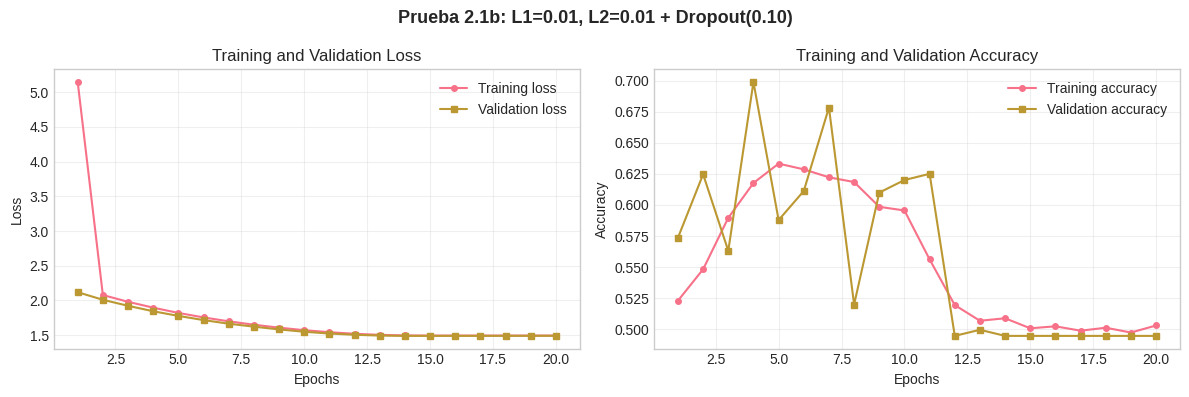

In [46]:
# PRUEBA 2.1b: L1=0.01, L2=0.01 + Dropout(0.10)
m = construir_modelo(dropout_rate=0.10, l1=0.01, l2=0.01)
h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
graficar(h, 'Prueba 2.1b: L1=0.01, L2=0.01 + Dropout(0.10)')

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - binary_accuracy: 0.5049 - loss: 9.5182 - val_binary_accuracy: 0.6160 - val_loss: 3.4751
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - binary_accuracy: 0.5474 - loss: 3.3966 - val_binary_accuracy: 0.6103 - val_loss: 3.2677
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - binary_accuracy: 0.5560 - loss: 3.2104 - val_binary_accuracy: 0.4956 - val_loss: 3.1032
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.5726 - loss: 3.0506 - val_binary_accuracy: 0.5696 - val_loss: 2.9556
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.5670 - loss: 2.9086 - val_binary_accuracy: 0.4947 - val_loss: 2.8302
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.5663 - loss: 2.7827 - val_binary_accuracy: 0.4947 - val_loss: 2.7102
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.5680 - loss: 2.6732 - val_binary_accuracy: 0.5032 - val_loss: 2.6095
Epoch 8/20
30

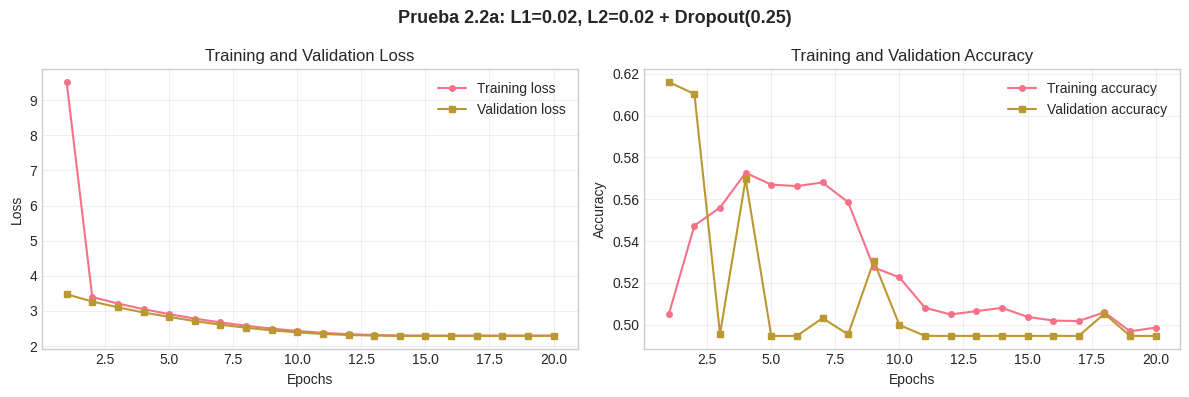

In [47]:
# PRUEBA 2.2a: L1=0.02, L2=0.02 + Dropout(0.25)
m = construir_modelo(dropout_rate=0.25, l1=0.02, l2=0.02)
h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
graficar(h, 'Prueba 2.2a: L1=0.02, L2=0.02 + Dropout(0.25)')

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - binary_accuracy: 0.4962 - loss: 9.5330 - val_binary_accuracy: 0.4947 - val_loss: 3.4724
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - binary_accuracy: 0.5037 - loss: 3.3956 - val_binary_accuracy: 0.4947 - val_loss: 3.2572
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - binary_accuracy: 0.5061 - loss: 3.2094 - val_binary_accuracy: 0.4993 - val_loss: 3.0909
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.5127 - loss: 3.0492 - val_binary_accuracy: 0.4947 - val_loss: 2.9440
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - binary_accuracy: 0.5155 - loss: 2.9070 - val_binary_accuracy: 0.4947 - val_loss: 2.8119
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - binary_accuracy: 0.5073 - loss: 2.7806 - val_binary_accuracy: 0.5419 - val_loss: 2.6960
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - binary_accuracy: 0.5171 - loss: 2.6703 - val_binary_accuracy: 0.5052 - val_loss: 2.5966
Epoch 8/20
30

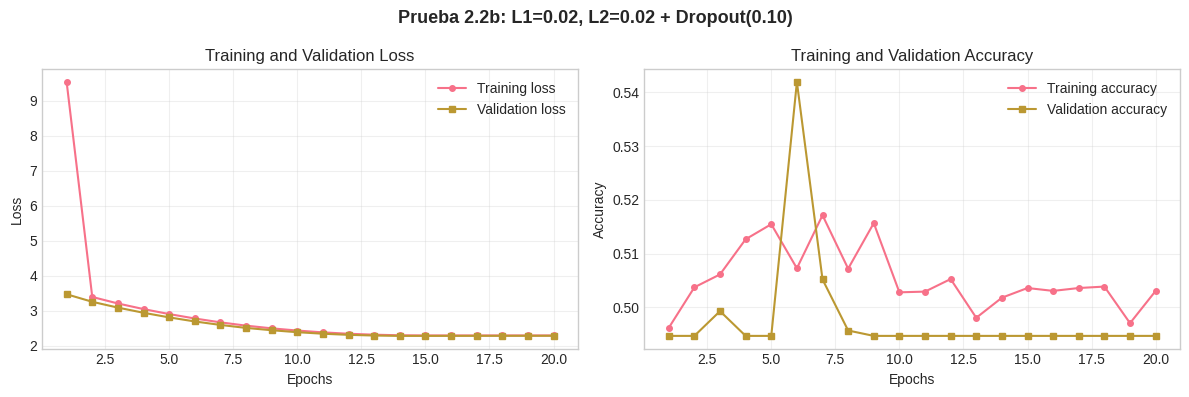

In [48]:
# PRUEBA 2.2b: L1=0.02, L2=0.02 + Dropout(0.10)
m = construir_modelo(dropout_rate=0.10, l1=0.02, l2=0.02)
h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
graficar(h, 'Prueba 2.2b: L1=0.02, L2=0.02 + Dropout(0.10)')

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - binary_accuracy: 0.5203 - loss: 5.3112 - val_binary_accuracy: 0.5076 - val_loss: 2.2176
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - binary_accuracy: 0.5595 - loss: 2.1576 - val_binary_accuracy: 0.5024 - val_loss: 2.0892
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.6135 - loss: 2.0398 - val_binary_accuracy: 0.6552 - val_loss: 1.9816
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.6293 - loss: 1.9400 - val_binary_accuracy: 0.5867 - val_loss: 1.8926
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.6323 - loss: 1.8523 - val_binary_accuracy: 0.6259 - val_loss: 1.8113
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.6325 - loss: 1.7755 - val_binary_accuracy: 0.6970 - val_loss: 1.7384
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.6341 - loss: 1.7093 - val_binary_accuracy: 0.7022 - val_loss: 1.6780
Epoch 8/20
30

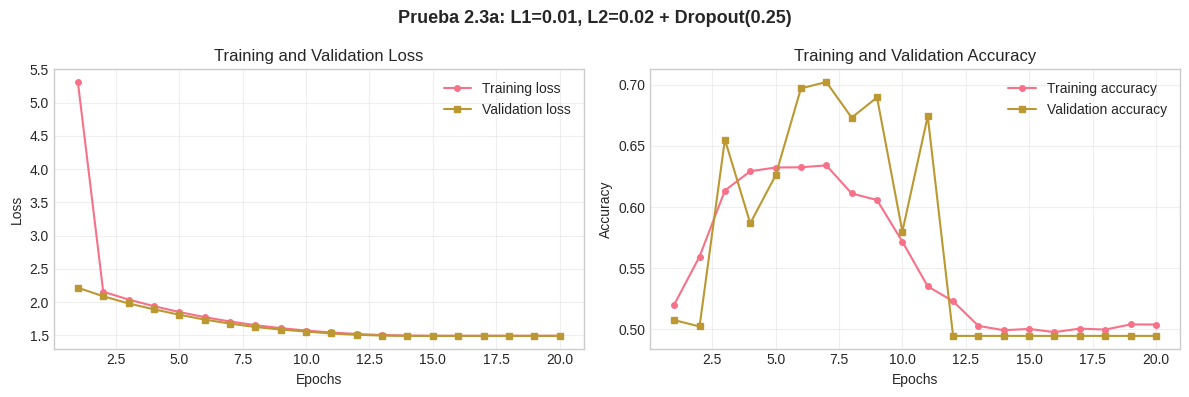

In [49]:
# PRUEBA 2.3a: L1=0.01, L2=0.02 + Dropout(0.25)
m = construir_modelo(dropout_rate=0.25, l1=0.01, l2=0.02)
h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
graficar(h, 'Prueba 2.3a: L1=0.01, L2=0.02 + Dropout(0.25)')

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - binary_accuracy: 0.5477 - loss: 5.2168 - val_binary_accuracy: 0.6166 - val_loss: 2.1305
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - binary_accuracy: 0.6090 - loss: 2.0748 - val_binary_accuracy: 0.6743 - val_loss: 2.0019
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - binary_accuracy: 0.6503 - loss: 1.9637 - val_binary_accuracy: 0.6319 - val_loss: 1.9076
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - binary_accuracy: 0.6648 - loss: 1.8711 - val_binary_accuracy: 0.7314 - val_loss: 1.8232
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - binary_accuracy: 0.6618 - loss: 1.7934 - val_binary_accuracy: 0.6636 - val_loss: 1.7559
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - binary_accuracy: 0.6723 - loss: 1.7275 - val_binary_accuracy: 0.6851 - val_loss: 1.6962
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.6864 - loss: 1.6708 - val_binary_accuracy: 0.7205 - val_loss: 1.6432
Epoch 8/20
30

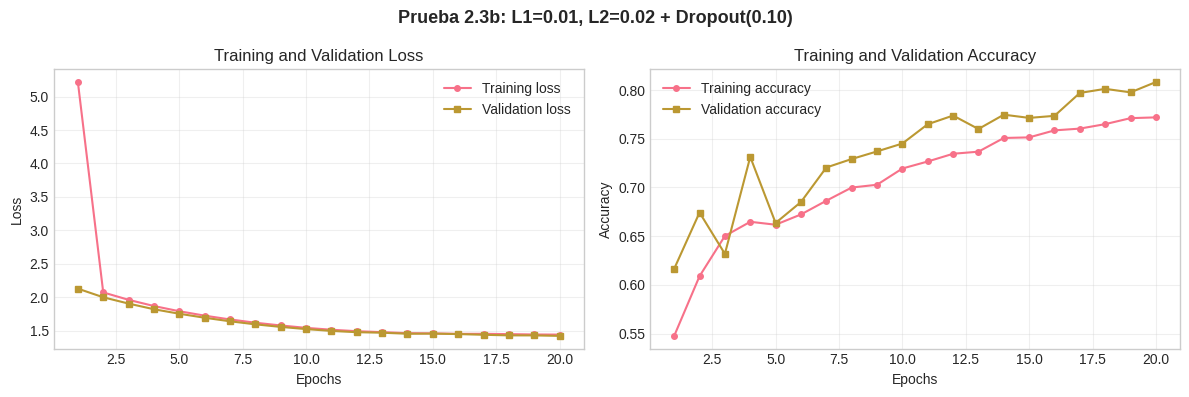

In [50]:
# PRUEBA 2.3b: L1=0.01, L2=0.02 + Dropout(0.10)
m = construir_modelo(dropout_rate=0.10, l1=0.01, l2=0.02)
h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
graficar(h, 'Prueba 2.3b: L1=0.01, L2=0.02 + Dropout(0.10)')

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - binary_accuracy: 0.5057 - loss: 9.2776 - val_binary_accuracy: 0.4947 - val_loss: 3.3048
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - binary_accuracy: 0.5049 - loss: 3.2417 - val_binary_accuracy: 0.4947 - val_loss: 3.1176
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - binary_accuracy: 0.5045 - loss: 3.0810 - val_binary_accuracy: 0.4945 - val_loss: 2.9773
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.5121 - loss: 2.9465 - val_binary_accuracy: 0.4956 - val_loss: 2.8516
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - binary_accuracy: 0.5177 - loss: 2.8280 - val_binary_accuracy: 0.4947 - val_loss: 2.7422
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - binary_accuracy: 0.5279 - loss: 2.7227 - val_binary_accuracy: 0.4973 - val_loss: 2.6423
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.5069 - loss: 2.6279 - val_binary_accuracy: 0.5307 - val_loss: 2.5562
Epoch 8/20
30

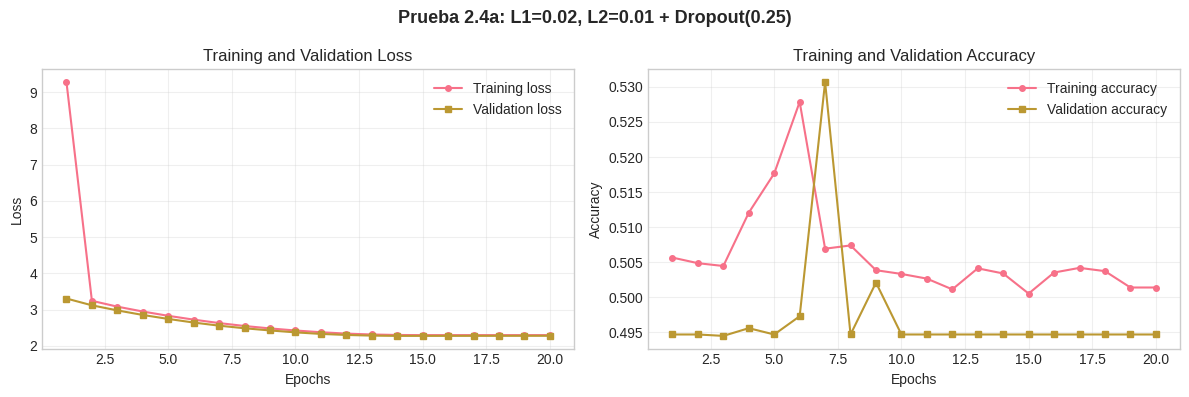

In [51]:
# PRUEBA 2.4a: L1=0.02, L2=0.01 + Dropout(0.25)
m = construir_modelo(dropout_rate=0.25, l1=0.02, l2=0.01)
h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
graficar(h, 'Prueba 2.4a: L1=0.02, L2=0.01 + Dropout(0.25)')

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - binary_accuracy: 0.4899 - loss: 9.3265 - val_binary_accuracy: 0.4947 - val_loss: 3.3363
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - binary_accuracy: 0.5035 - loss: 3.2730 - val_binary_accuracy: 0.4947 - val_loss: 3.1421
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.5035 - loss: 3.1061 - val_binary_accuracy: 0.4947 - val_loss: 2.9931
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.5035 - loss: 2.9642 - val_binary_accuracy: 0.4947 - val_loss: 2.8609
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - binary_accuracy: 0.5035 - loss: 2.8375 - val_binary_accuracy: 0.4947 - val_loss: 2.7424
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - binary_accuracy: 0.5083 - loss: 2.7253 - val_binary_accuracy: 0.4947 - val_loss: 2.6388
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - binary_accuracy: 0.5039 - loss: 2.6264 - val_binary_accuracy: 0.4954 - val_loss: 2.5478
Epoch 8/20
30

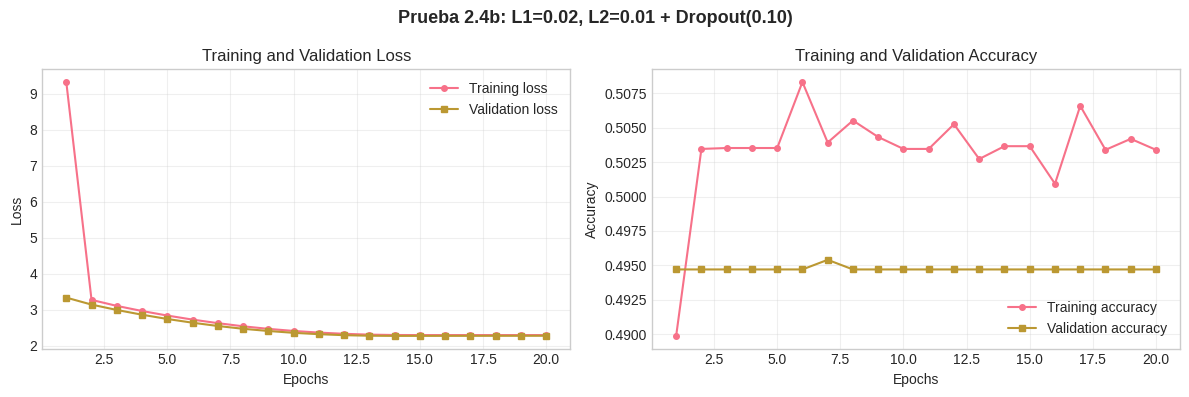

In [52]:
# PRUEBA 2.4b: L1=0.02, L2=0.01 + Dropout(0.10)
m = construir_modelo(dropout_rate=0.10, l1=0.02, l2=0.01)
h = m.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))
graficar(h, 'Prueba 2.4b: L1=0.02, L2=0.01 + Dropout(0.10)')

## Conclusiones del Problema 3
En el Problema 3 se evaluó el efecto de combinar Dropout con regularización L1/L2 sobre el overfitting. Los resultados mostraron que en la mayoría de las pruebas, agregar Dropout a los modelos del Problema 2 empeoró el rendimiento en lugar de mejorarlo. Las combinaciones con Dropout(0.25) resultaron demasiado restrictivas, llevando al modelo a colapsar en un 50% de precisión en casi todos los casos. Las combinaciones con L1=0.02 fueron especialmente problemáticas, ya que independientemente de la tasa de Dropout aplicada, el modelo no logró superar el 53% de precisión, equivalente a adivinar al azar.
La única excepción positiva fue la Prueba 2.3b (L1=0.01, L2=0.02 + Dropout(0.10)), que logró mantener una precisión de ~80-82% con las líneas de entrenamiento y validación avanzando juntas de forma estable, siendo la única combinación del Problema 3 comparable a los mejores resultados del Problema 2.
En conclusión, el Dropout por sí solo con tasas bajas (como en las Pruebas 1.1 y 1.2) tuvo poco impacto sobre el overfitting. Combinado con regularización L1/L2 fuerte, destruyó la capacidad de aprendizaje del modelo. Solo con valores moderados de regularización y un Dropout pequeño se logró mantener un balance aceptable. La mejor estrategia para este problema sigue siendo L1=0.01, L2=0.02, con o sin un Dropout muy pequeño.